In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
# fixed = pd.read_csv("../data/fix_param_test_1.csv")
test_df = pd.read_csv("../data/asymmetry_test_1.csv")

In [6]:
test_df.shape

(100, 22)

In [7]:
test_df.describe()

,Total Kinase,Total Phosphatase,Timestep,Patch Length,dPIP,alphaEnzyme,k_mkon,k_koff,p_mkon,p_koff,...,p_mkcat,p_mKm,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X
count,100.000000,100.000000,1.000000e+02,100.0,100.0,1.000000e+02,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,532.131631,507.705871,1.000000e-02,0.5,3.0,2.000000e-01,0.045577,0.200301,0.252932,0.051595,...,15.0,0.5,417.160000,80.750000,2.401743e-01,4.116635e-01,1.354658e-01,1.527037e-01,4.772989e-01,2.942830e-01
std,274.405632,286.334837,1.743463e-18,0.0,0.0,5.579081e-17,0.026288,0.137013,0.146985,0.027884,...,0.0,0.0,266.078545,150.575487,2.588217e-01,3.856421e-01,2.767596e-01,2.994631e-01,4.319691e-01,2.570894e-01
min,14.329337,16.420461,1.000000e-02,0.5,3.0,2.000000e-01,0.003252,0.009968,0.005510,0.001555,...,15.0,0.5,1.000000,0.000000,1.493936e-22,4.896081e-27,1.066168e-35,1.751423e-33,4.155218e-26,1.252860e-22
25%,281.107947,268.458792,1.000000e-02,0.5,3.0,2.000000e-01,0.023583,0.086251,0.145172,0.029808,...,15.0,0.5,167.500000,6.750000,1.741318e-02,1.660911e-03,3.089482e-16,4.826179e-11,2.256713e-04,4.848710e-02
50%,541.114998,540.881539,1.000000e-02,0.5,3.0,2.000000e-01,0.040643,0.162908,0.262862,0.049257,...,15.0,0.5,390.500000,35.000000,1.655401e-01,2.790891e-01,2.485219e-08,1.279781e-04,4.724908e-01,2.440826e-01
75%,762.886886,767.838261,1.000000e-02,0.5,3.0,2.000000e-01,0.066843,0.305734,0.378568,0.076861,...,15.0,0.5,611.000000,76.750000,3.494320e-01,8.331791e-01,6.520296e-02,9.123589e-02,9.593441e-01,4.476219e-01
max,997.337550,985.272006,1.000000e-02,0.5,3.0,2.000000e-01,0.094330,0.490056,0.497735,0.099964,...,15.0,0.5,997.000000,908.000000,9.981755e-01,9.999982e-01,9.993025e-01,1.000000e+00,1.000000e+00,9.783133e-01


In [8]:
result = test_df.iloc[:, 14:]
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X
0,135,3,2.388019e-01,1.831118e-02,3.496741e-01,8.755303e-02,1.366797e-03,1.142263e-01
1,156,6,1.332681e-01,9.700677e-01,1.294339e-07,1.629201e-01,1.519353e-02,2.870454e-01
2,607,184,2.920381e-22,4.893329e-22,5.103879e-25,7.685619e-24,3.615249e-24,1.252860e-22
3,570,51,1.881900e-02,1.178689e-06,5.505139e-20,2.460400e-15,7.104625e-01,1.776159e-01
4,431,73,3.195107e-02,1.440886e-02,9.817205e-14,4.354613e-11,9.465259e-01,2.402337e-01


In [9]:
df = result
for i in range(1, 5):
    result['Polarization Index ' + str(i)] = (df['Average Node ' + str(i) + ' X'] / df['Average Body X'])
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X,Polarization Index 1,Polarization Index 2,Polarization Index 3,Polarization Index 4
0,135,3,2.388019e-01,1.831118e-02,3.496741e-01,8.755303e-02,1.366797e-03,1.142263e-01,0.076679,1.464285e+00,3.666345e-01,0.005724
1,156,6,1.332681e-01,9.700677e-01,1.294339e-07,1.629201e-01,1.519353e-02,2.870454e-01,7.279066,9.712292e-07,1.222498e+00,0.114007
2,607,184,2.920381e-22,4.893329e-22,5.103879e-25,7.685619e-24,3.615249e-24,1.252860e-22,1.675579,1.747676e-03,2.631718e-02,0.012379
3,570,51,1.881900e-02,1.178689e-06,5.505139e-20,2.460400e-15,7.104625e-01,1.776159e-01,0.000063,2.925308e-18,1.307402e-13,37.752399
4,431,73,3.195107e-02,1.440886e-02,9.817205e-14,4.354613e-11,9.465259e-01,2.402337e-01,0.450967,3.072575e-12,1.362901e-09,29.624235


In [10]:
df = result
for i in range(1, 5):
    df['Node ' + str(i) + ' is Polarized'] = df['Polarization Index ' + str(i)] > 1.5
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X,Polarization Index 1,Polarization Index 2,Polarization Index 3,Polarization Index 4,Node 1 is Polarized,Node 2 is Polarized,Node 3 is Polarized,Node 4 is Polarized
0,135,3,2.388019e-01,1.831118e-02,3.496741e-01,8.755303e-02,1.366797e-03,1.142263e-01,0.076679,1.464285e+00,3.666345e-01,0.005724,False,False,False,False
1,156,6,1.332681e-01,9.700677e-01,1.294339e-07,1.629201e-01,1.519353e-02,2.870454e-01,7.279066,9.712292e-07,1.222498e+00,0.114007,True,False,False,False
2,607,184,2.920381e-22,4.893329e-22,5.103879e-25,7.685619e-24,3.615249e-24,1.252860e-22,1.675579,1.747676e-03,2.631718e-02,0.012379,True,False,False,False
3,570,51,1.881900e-02,1.178689e-06,5.505139e-20,2.460400e-15,7.104625e-01,1.776159e-01,0.000063,2.925308e-18,1.307402e-13,37.752399,False,False,False,True
4,431,73,3.195107e-02,1.440886e-02,9.817205e-14,4.354613e-11,9.465259e-01,2.402337e-01,0.450967,3.072575e-12,1.362901e-09,29.624235,False,False,False,True


In [11]:
node_polarization = result.iloc[:, 12:16].sum().tolist()
node_polarization

[51, 6, 6, 48]

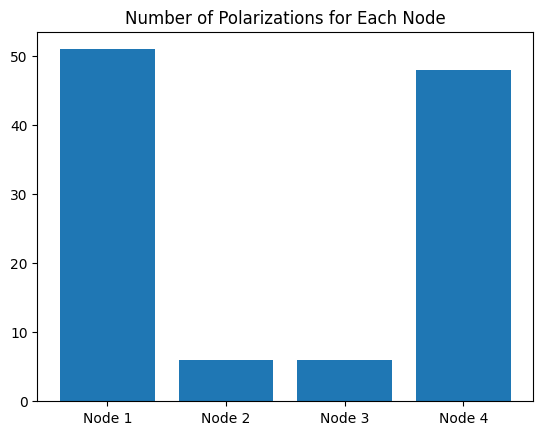

In [12]:
cat = ['Node 1', 'Node 2', 'Node 3', 'Node 4']
plt.bar(cat, node_polarization)
plt.title('Number of Polarizations for Each Node');

In [13]:
node_cols = [f'Node {i} is Polarized' for i in range(1, 5)]
result['Number of Polarized Nodes'] = result[node_cols].sum(axis=1)
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X,Polarization Index 1,Polarization Index 2,Polarization Index 3,Polarization Index 4,Node 1 is Polarized,Node 2 is Polarized,Node 3 is Polarized,Node 4 is Polarized,Number of Polarized Nodes
0,135,3,2.388019e-01,1.831118e-02,3.496741e-01,8.755303e-02,1.366797e-03,1.142263e-01,0.076679,1.464285e+00,3.666345e-01,0.005724,False,False,False,False,0
1,156,6,1.332681e-01,9.700677e-01,1.294339e-07,1.629201e-01,1.519353e-02,2.870454e-01,7.279066,9.712292e-07,1.222498e+00,0.114007,True,False,False,False,1
2,607,184,2.920381e-22,4.893329e-22,5.103879e-25,7.685619e-24,3.615249e-24,1.252860e-22,1.675579,1.747676e-03,2.631718e-02,0.012379,True,False,False,False,1
3,570,51,1.881900e-02,1.178689e-06,5.505139e-20,2.460400e-15,7.104625e-01,1.776159e-01,0.000063,2.925308e-18,1.307402e-13,37.752399,False,False,False,True,1
4,431,73,3.195107e-02,1.440886e-02,9.817205e-14,4.354613e-11,9.465259e-01,2.402337e-01,0.450967,3.072575e-12,1.362901e-09,29.624235,False,False,False,True,1


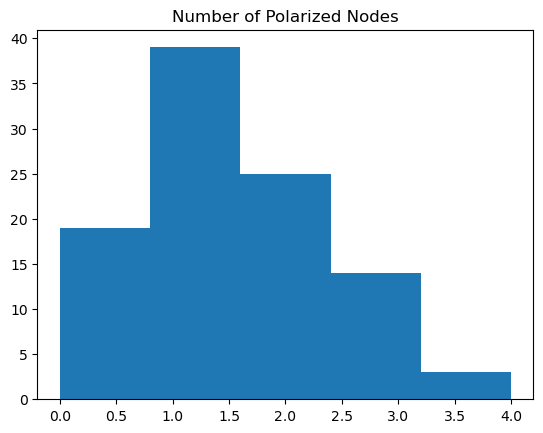

In [15]:
plt.hist(result['Number of Polarized Nodes'], bins=5)
plt.title('Number of Polarized Nodes');